# **Unsupervised Machine Learning**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Clustering**
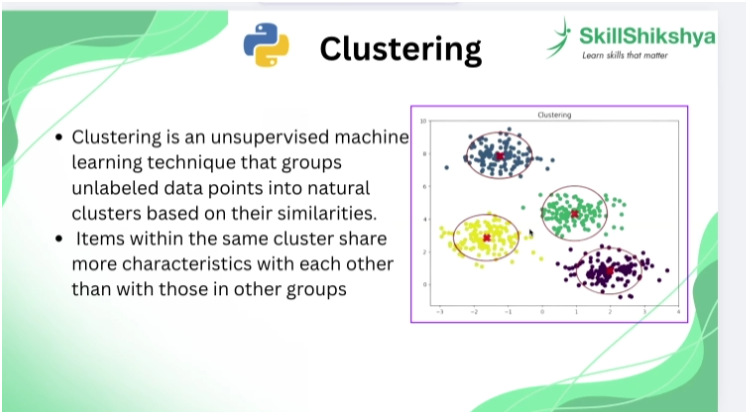

**usecases of clustering**

- market segmentation
- document clustering
- image segmentation

# **1) K-means Clustering**

- k means number of clusters
- finds eucledian distance between the center of the data (centroid) and other points then finds the perfect line

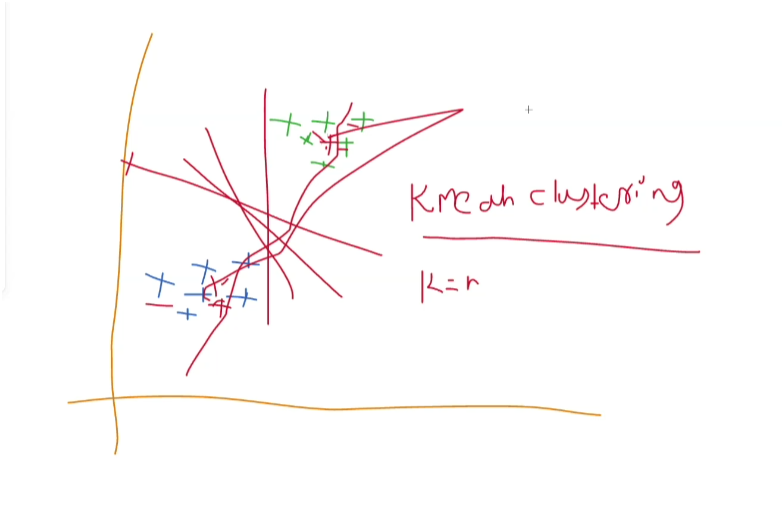

**steps**
- choose k
- initialize centroid
- assign points
- recompute centroid
  - for finding centroid we use to find by using eucledian distance
  - for finding value of k we use elbow method and silhoute method

**Elbow method**
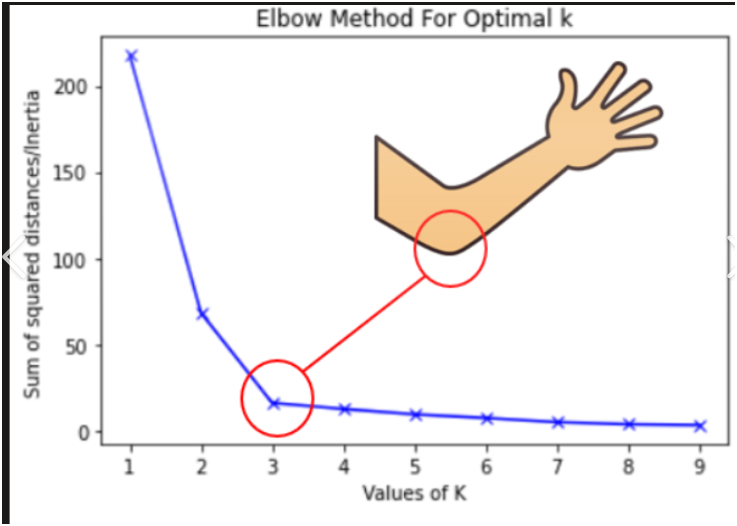

In [2]:
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [3]:
iris_df = load_iris()

X = iris_df.data
y = iris_df.target

In [4]:
scaler = StandardScaler()

In [5]:
X_scaled = scaler.fit_transform(X)

# **Elbow Method**

In [6]:
inertia = []
for k in range(1,11): # test k for 1 to 10
  kmeans = KMeans(n_clusters = k, random_state = 42)
  kmeans.fit(X_scaled)
  inertia.append(kmeans.inertia_) # sum of squared distance to cluster center

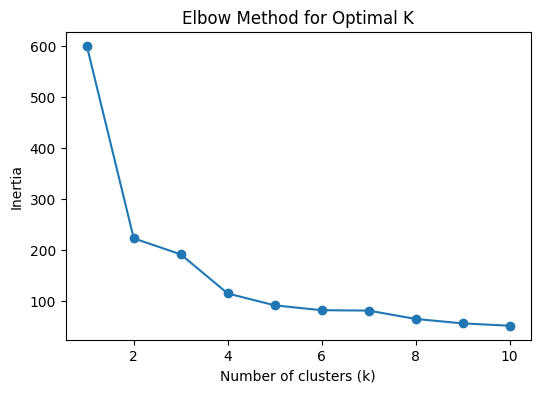

In [9]:
plt.figure(figsize = (6,4))
plt.plot(range(1,11), inertia, marker = "o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.show()

# **Silhouette Method**

In [10]:
from sklearn.metrics import silhouette_score

In [17]:
silhoutte_scores = []
for k in range(2,11):
  kmeans = KMeans(n_clusters = k,random_state = 42)
  labels_temp = kmeans.fit_predict(X_scaled)
  score = silhouette_score(X_scaled,labels_temp)
  silhoutte_scores.append(score)

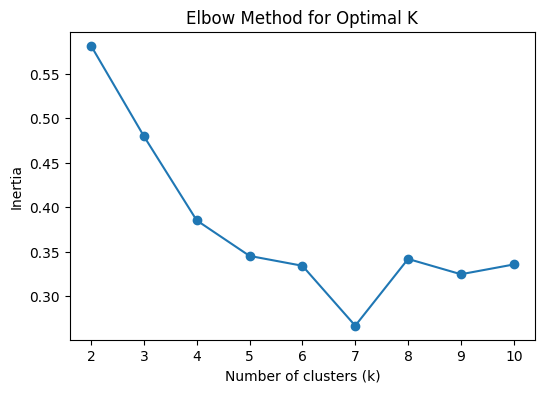

In [19]:
plt.figure(figsize = (6,4))
plt.plot(range(2,11), silhoutte_scores, marker = "o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.show()

**why to start silhoutte_score from 2?**
- because we cannot calculate the silhoutte  of single cluster

In [20]:
best_k = range(2,11)[silhoutte_scores.index(max(silhoutte_scores))]
print("Best K silhoutte :",best_k)

Best K silhoutte : 2


In [21]:
kmeans = KMeans(n_clusters = 3,random_state= 42)
kmeans.fit(X_scaled)

KMeans(n_clusters=3, random_state=42)

In [23]:
labels = kmeans.labels_
centroids = kmeans.cluster_centers_

In [24]:
labels

array([1, 2, 2, 2, 1, 1, 1, 1, 2, 2, 1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 2, 1, 1, 1, 2, 2, 1, 1, 1, 2, 2, 1, 1, 2, 1, 1, 2, 2, 1,
       1, 2, 1, 2, 1, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 2, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int32)

In [25]:
centroids

array([[ 0.57100359, -0.37176778,  0.69111943,  0.66315198],
       [-0.81623084,  1.31895771, -1.28683379, -1.2197118 ],
       [-1.32765367, -0.373138  , -1.13723572, -1.11486192]])

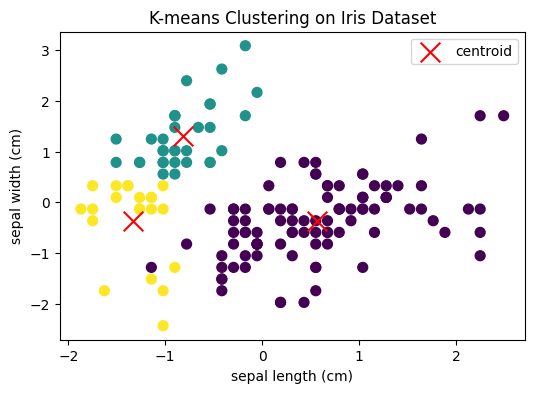

In [30]:
plt.figure(figsize = (6,4))
plt.scatter(X_scaled[:,0],X_scaled[:,1],c = labels,cmap ="viridis",s = 50)
plt.scatter(kmeans.cluster_centers_[:,0],kmeans.cluster_centers_[:,1],c = "red",marker ="x",s = 200,label = "centroid")
plt.xlabel(iris_df.feature_names[0])
plt.ylabel(iris_df.feature_names[1])
plt.title("K-means Clustering on Iris Dataset")
plt.legend()
plt.show()

**predicting**

In [33]:
print("Enter new Iris flower features:")
sepal_length = float(input("Sepal length (cm): "))
sepal_width = float(input("Sepal width (cm): "))
petal_length = float(input("Petal length (cm): "))
petal_width = float(input("Petal width (cm): "))

new_sample = np.array([[sepal_length, sepal_width, petal_length,petal_width]])

# scaling the input
new_sample_scaled = scaler.transform(new_sample)

#predicting the output
cluster = kmeans.predict(new_sample_scaled)
print("The new sample belongs to cluster: ",cluster[0])

Enter new Iris flowe features:
Sepal length (cm): 5.1
Sepal width (cm): 3.5
Petal length (cm): 1.4
Petal width (cm): 0.2
The new sample belongs to cluster:  1


# **2) Hierarchial Clustering**
- also called dendogram

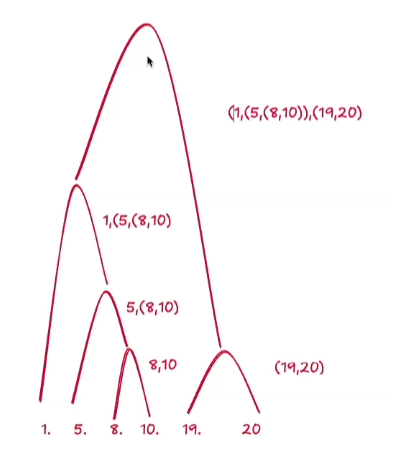

- proxy matrix

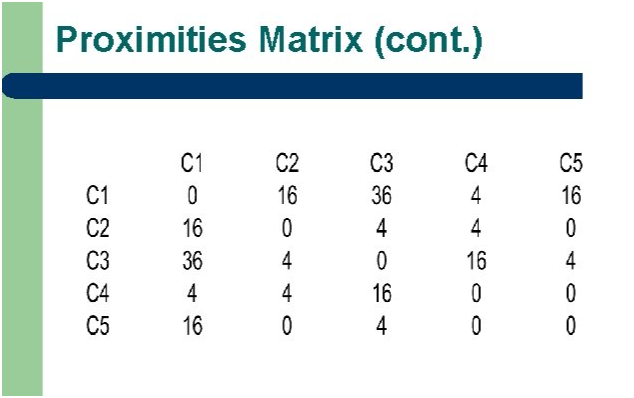

- also called agglomerative clustering

# **Divisive clustering**


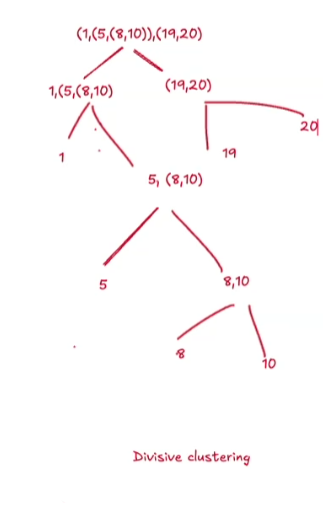

# **3) DB-Scan Clustering**
- stands for Density Based Spatial Clustering of Application with Noise
- epsilon => is the maximum radius of the neighborhood around a point within which other points are considered its neighbors for forming clusters.
- min_point =>  given values of the epsilon point
- core_point => has >= minpoints neighbors within the epsilon
- border_point => has < minpoints neighbors with in the epsilon
- noise_point => missed points while making epsilon (outlier)

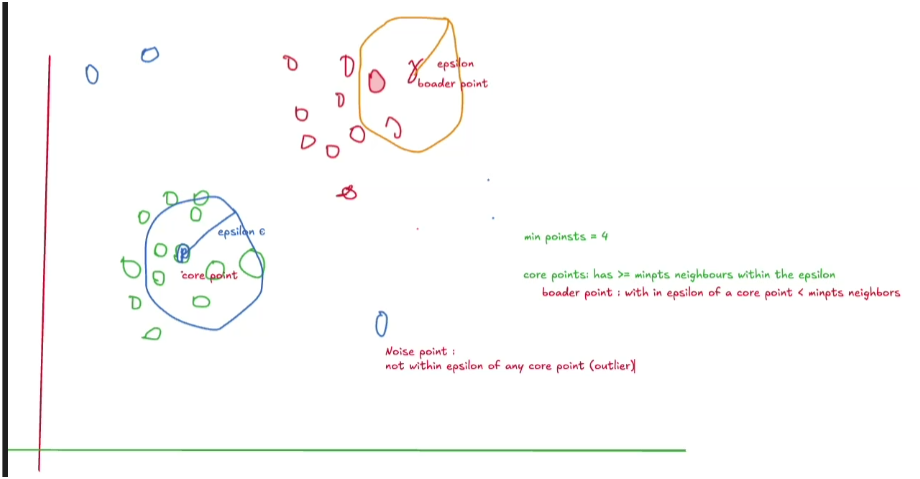